In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from smalldiffusion.model_unet import myUnet
from smalldiffusion.model import Scaled

%load_ext autoreload
%autoreload 2

# Pick a region
# wave = np.load('../datasets/wave_mean.npy')
# forcing = np.load('../datasets/forcing.npy')    
# np.save('../datasets/train/wave.npy', wave[:401,:,50:114,0:64])
# np.save('../datasets/train/forcing.npy', forcing[:401,:,50:114,0:64])
# np.save('../datasets/test/wave.npy', wave[402:,:,50:114,0:64])
# np.save('../datasets/test/forcing.npy', forcing[402:,:,50:114,0:64])

# mask = np.load('../datasets/mask.npy')
# np.save('../datasets/train/mask.npy', mask[50:114,0:64])
# np.save('../datasets/test/mask.npy', mask[50:114,0:64])

/Users/jwu/miniconda3/envs/mlflux/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jwu/miniconda3/envs/mlflux/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/jwu/miniconda3/envs/mlflux/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <C1CC76AA-CD55-3E10-9064-29676E3E2535> /Users/jwu/miniconda3/envs/mlflux/lib/python3.11/site-packages/torchvision/image.so
  Expected in:     <44DEDA27-4DE9-3D4A-8EDE-5AA72081319F> /Users/jwu/miniconda3/envs/mlflux/lib/python3.11/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with

In [3]:
from smalldiffusion.data import npyData
from torch.utils.data import DataLoader
from smalldiffusion.diffusion import ScheduleLogLinear
from accelerate import Accelerator
a = Accelerator()

train = npyData('../datasets/train/wave.npy', '../datasets/train/forcing.npy', '../datasets/train/mask.npy', compute_stats=True)
test = npyData('../datasets/test/wave.npy', '../datasets/test/forcing.npy', '../datasets/test/mask.npy', compute_stats=False,
               meanx=train.meanx, stdx=train.stdx, meanf=train.meanf, stdf=train.stdf)

loader = DataLoader(train, batch_size=8, shuffle=True)
schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=20, N=80)

Computing dataset mean and std...


In [50]:
RESUME = True
weights_file = '../run/results/checkpoint.pth'
    
model = Scaled(myUnet)(in_dim=64, in_ch=4, out_ch=4, ch=64, precond_ch=3, 
                       ch_mult=(1, 2, 2), attn_resolutions=(16,))
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

if RESUME:
    model.load_state_dict(torch.load(weights_file, map_location='cpu'))    

model, optimizer, loader = a.prepare(model, optimizer, loader)

In [51]:
def plot_sample(x, x_true, f):
    fig, axes = plt.subplots(2, 6, figsize=[22, 6], dpi=100)
    titles = ['wave height','wave length','direction','spread','wind u','wind v']
    imgs = [
        axes[0, 0].imshow(x_true[0], vmin=0, vmax=10, cmap='Blues'),
        axes[0, 1].imshow(x_true[1], vmin=0, vmax=600, cmap='Reds'),
        axes[0, 2].imshow(x_true[2], vmin=0, vmax=360, cmap='twilight_r'),
        axes[0, 3].imshow(x_true[3], vmin=0, vmax=90, cmap='Grays'),
        axes[0, 4].imshow(f[0]),
        axes[0, 5].imshow(f[1]),
    ]
    imgs_sample =[
        axes[1, 0].imshow(x[0], vmin=0, vmax=15, cmap='Blues'),
        axes[1, 1].imshow(x[1], vmin=0, vmax=200, cmap='Reds'),
        axes[1, 2].imshow(x[2], vmin=0, vmax=360, cmap='twilight_r'),
        axes[1, 3].imshow(x[3], vmin=0, vmax=90, cmap='Grays'),
        axes[1, 4].imshow(f[0]),
        axes[1, 5].imshow(f[1]),
    ]
    for j in range(6):
        axes[0,j].set_title(titles[j])
        fig.colorbar(imgs[j], ax=axes[0,j], fraction=0.046, pad=0.04)
        fig.colorbar(imgs_sample[j], ax=axes[1,j], fraction=0.046, pad=0.04)
        
    fig.text(0.02, 0.72, "Truth", va='center', ha='left', fontsize=14)
    fig.text(0.02, 0.28, "Sampled",     va='center', ha='left', fontsize=14)
    
    plt.tight_layout(rect=[0.06, 0, 1, 1])  # leave room on the left for text
    return fig

from smalldiffusion.diffusion import samples

loader_test = DataLoader(test, batch_size=2, shuffle=True)
loader_iter = iter(loader_test) 
x, f = next(loader_iter)
*xt, x0 = samples(model, schedule.sample_sigmas(20), gam=1.6, batchsize=2, accelerator=a, cond=f[:2])

In [59]:
*xt, x0 = samples(model, schedule.sample_sigmas(40), gam=1.6, batchsize=2, accelerator=a, cond=f[:2])

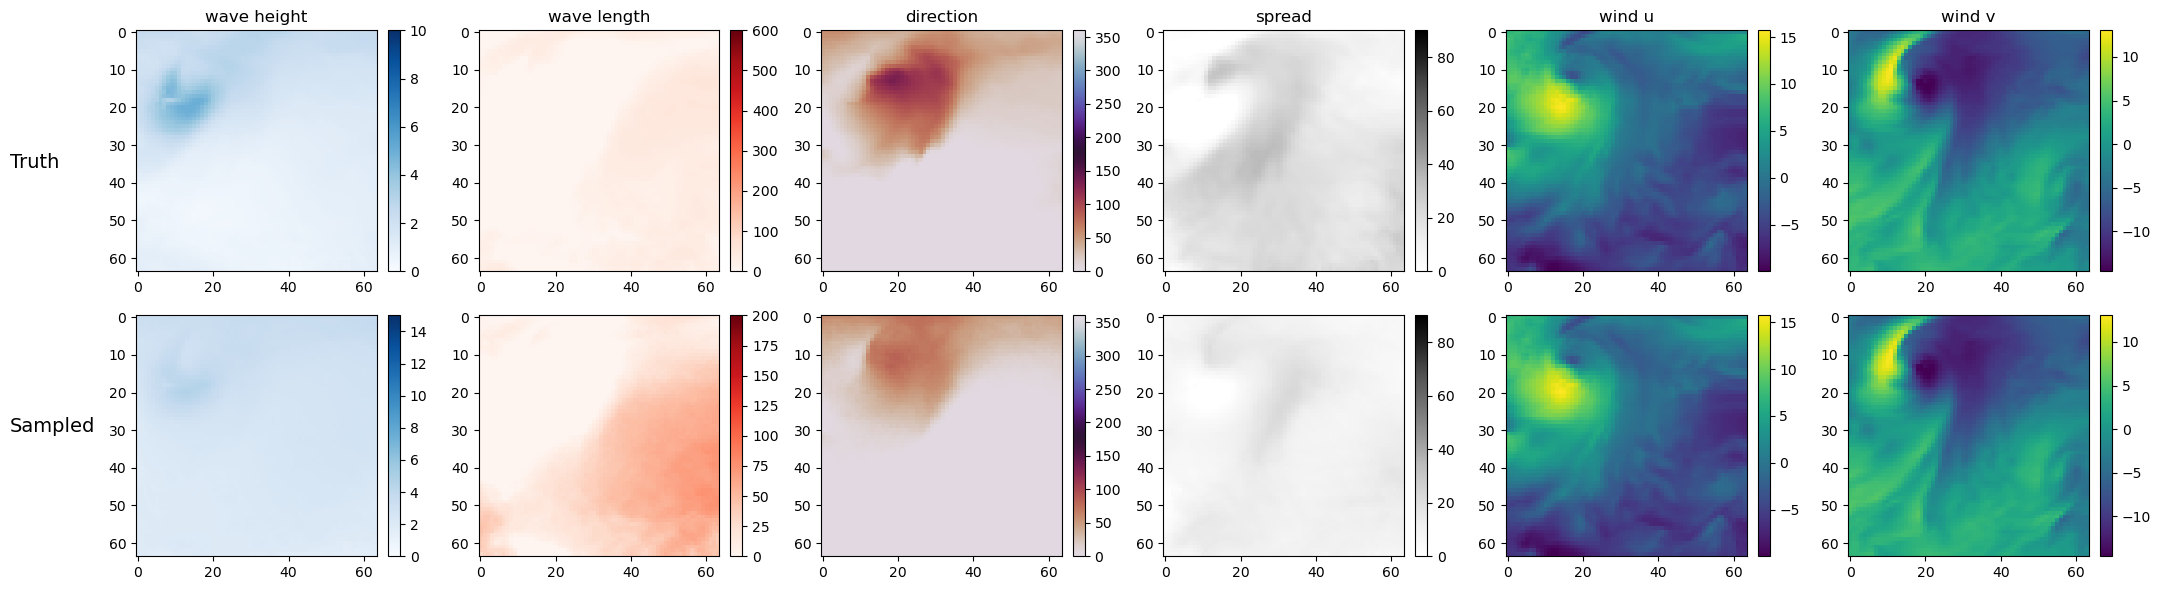

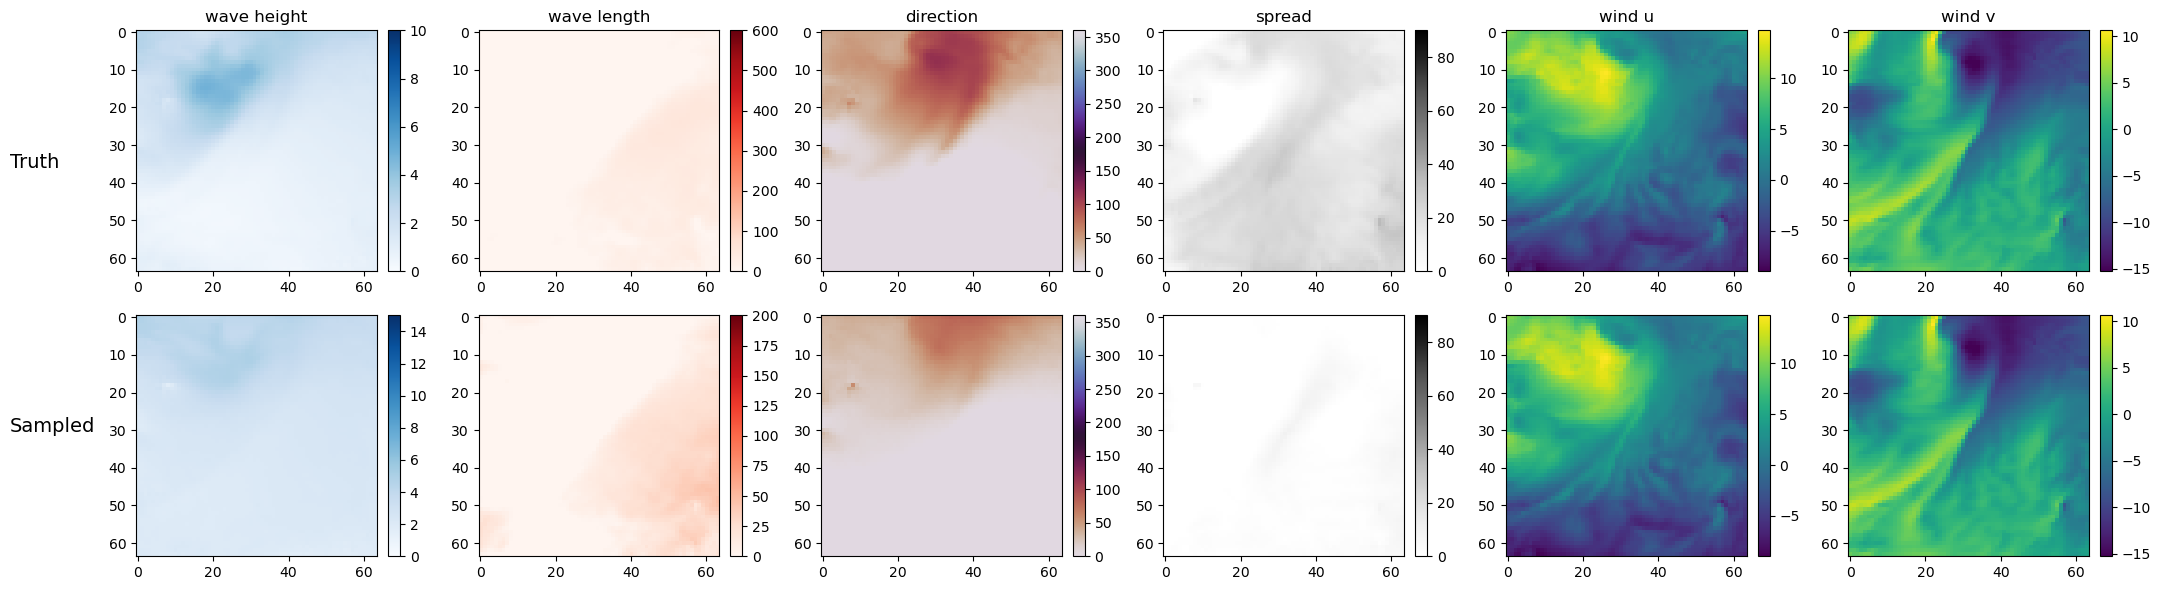

In [60]:
x0_ = train.inv_tf_x(x0)
x_ = train.inv_tf_x(x)
f_ = train.inv_tf_f(f)
for i in range(2):
    fig = plot_sample(x0_.detach().cpu().numpy()[i], x_.detach().cpu().numpy()[i], f_.detach().cpu().numpy()[i])
    fig.savefig('../run/results/' + f'sample{i}.png')

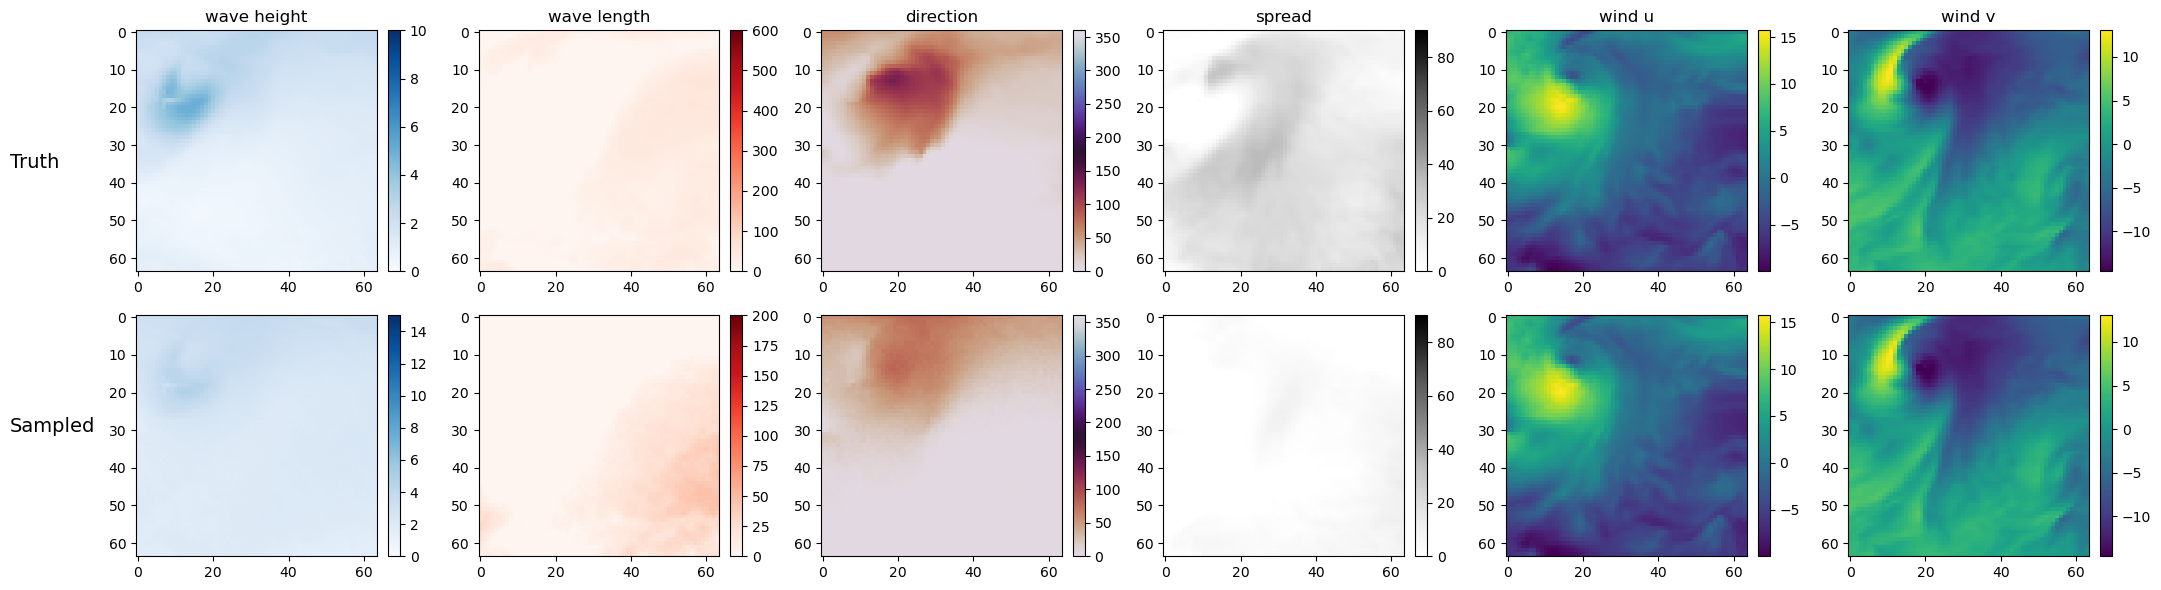

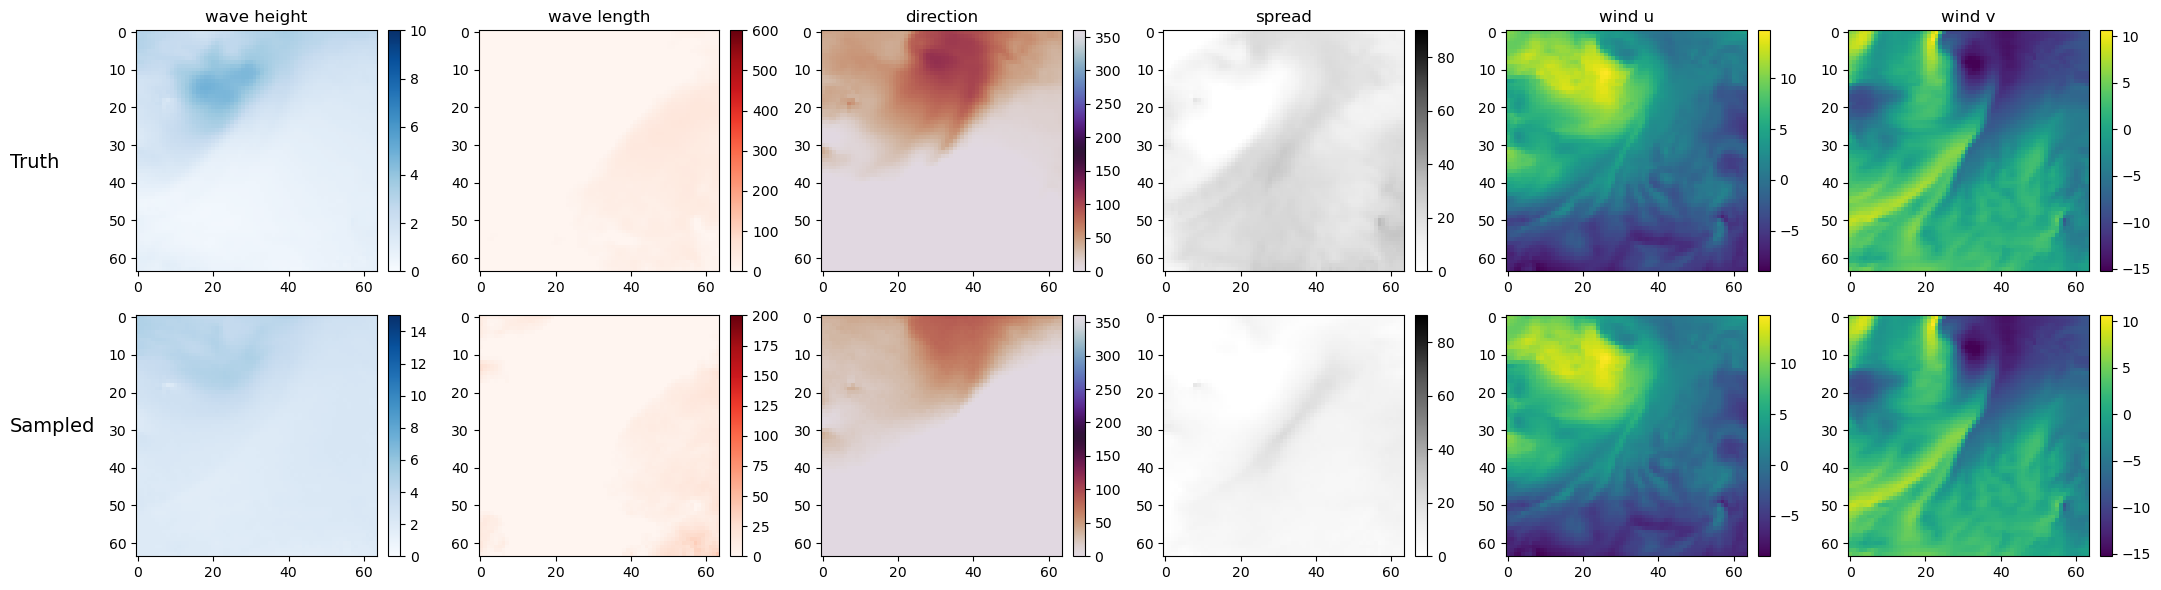

In [52]:
x0_ = train.inv_tf_x(x0)
x_ = train.inv_tf_x(x)
f_ = train.inv_tf_f(f)
for i in range(2):
    fig = plot_sample(x0_.detach().cpu().numpy()[i], x_.detach().cpu().numpy()[i], f_.detach().cpu().numpy()[i])
    fig.savefig('../run/results/' + f'sample{i}.png')

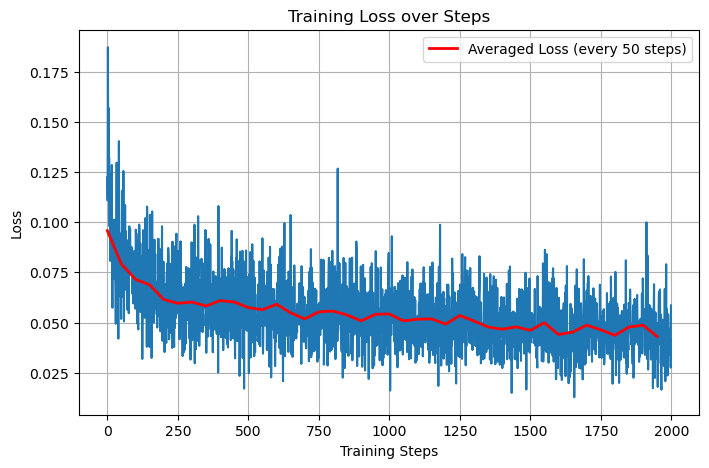

In [53]:
### Read in loss log and plot
losses = []
with open("../run/results/loss_log.txt", "r") as log_file:
    for line in log_file:
        losses.append(float(line.strip()))  
    
plt.figure(figsize=(8,5))
plt.plot(losses)
# Plot averaged loss every 50 steps
avg_losses = [np.mean(losses[i:i+50]) for i in range(0, len(losses), 50)]
plt.plot(range(0, len(losses), 50), avg_losses, color='red', linewidth=2, label='Averaged Loss (every 50 steps)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.grid()


In [43]:
print("Device:", a.device)
print("Is distributed:", a.distributed_type)
print("Num processes:", a.num_processes)
print("Mixed precision:", a.mixed_precision)
# print("Compute dtype:", a.compute_dtype)
# print("Param dtype:", a.dtype)

Device: mps
Is distributed: DistributedType.NO
Num processes: 1
Mixed precision: no
